In [ ]:
import tensorflow as tf
import random
# libraries for data manipulation
import numpy as np
import pandas as pd

# libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# MNIST is an inbuilt dataset on tensorflow
mnist = tf.keras.datasets.mnist

# split the data into test and train sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# check the size of the datsets
x_train.shape, x_test.shape

# We have 60000 datapoints in train dataset and 10000 datapoints in test dataset
# each denoting pixel information of a 28 * 28 image of a handwritten number

# Normalizing the data by divinding it with 255
# The reason is because the pixel values of the image can vary between 0-255
x_train, x_test = x_train / 255.0, x_test / 255.0

# combine the x , y train and test arrays into pandas dataframe for EDA purpose

# unwrapping the dataset such that each row contains the pixel information of
# each image and storing in the dataframe

# using the reshape function to convert a 3d array to 2d
# The number of rows remain same , the 28 * 28 matrix containing pixel info is
# unwrapped into a single row
mnist_train = pd.DataFrame(x_train.reshape(x_train.shape[0],
                                           x_train.shape[1] * x_train.shape[2]))

# repeat the same for test data
mnist_test = pd.DataFrame(x_test.reshape(x_test.shape[0],
                                           x_test.shape[1] * x_test.shape[2]))

# Create column names for dataframe to make it more readable
colnames = ['Pixel'+str(i) for i in range(1,785)]

mnist_train.columns = colnames
mnist_test.columns = colnames

# concatenate the labels into the test and train dataframe
mnist_train['label'] = y_train
mnist_test['label'] = y_test


mnist_train.head()

mnist_test.head()

# check if there is any NaN or missing datapoints
mnist_train.isnull().values.sum()

# check label distribution in test and train datasets
sns.countplot(x="label", data=mnist_train, palette="Set3").set(
    title="Label distribution in Training Data")

sns.countplot(x="label", data=mnist_test, palette="Set2").set(
    title="Label distribution in Test Data")

# visualise some of the images from train dataset
# display 4 images per row
fig, axes = plt.subplots(3,4, figsize=(10,5))
# set a tight layout for better spacing between plots
fig.tight_layout()
axes = axes.flatten()
# generate 12 random row numbers to select from mnist_train dataframe
idx = np.random.randint(0,mnist_train.shape[0],size=12)
for i in range(12):
    # get the row data
    pixel_data = mnist_train.iloc[idx[i]]
    # use imshow to build the image using pixel info
    # reshape is necessary because imshow expects a 2d array structure as input
    axes[i].imshow(np.array(pixel_data[:784]).reshape(28,28), cmap='gray')
    axes[i].axis('off')
    # add the label of the image as title
    axes[i].set_title(str(int(pixel_data[-1])), color= 'black', fontsize=20)

import xgboost as xb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# splitting the training data into train and validate datasets
x_train, x_val, y_train, y_val = train_test_split(x_train,
                                                  y_train,
                                                  test_size=0.1)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, BatchNormalization, LeakyReLU, Reshape, Conv2DTranspose
from tensorflow.keras import optimizers
from tensorflow.keras import models

# add a channel dimension to the images
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
x_val= np.expand_dims(x_val, axis=-1)

# one hot encoding all the labels
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)
y_val = to_categorical(y_val,10)

cnn_model = models.Sequential()

cnn_model.add(Conv2D(filters=20, kernel_size=(5, 5),
                   activation='relu', padding="same",
                   input_shape=(28,28,1)))
cnn_model.add(BatchNormalization(axis=-1))
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv2D(filters=20, kernel_size=(4, 4),
                   activation='relu', padding="same"))
cnn_model.add(BatchNormalization(axis=-1))
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv2D(filters=20, kernel_size=(4, 4),
                   activation='relu', padding="same"))
cnn_model.add(BatchNormalization(axis=-1))
cnn_model.add(Dropout(0.2))

cnn_model.add(Flatten())
cnn_model.add(Dense(200, activation='relu'))

cnn_model.add(Dense(10, activation='softmax'))

cnn_model_opt = optimizers.Adam(decay=1e-4)

print(cnn_model.summary())

cnn_model.compile(optimizer = cnn_model_opt , loss = "categorical_crossentropy",
                  metrics=["accuracy"])

cnn_model_fit = cnn_model.fit(x_train,
                        y_train,
                        validation_data = (x_val, y_val),
                        batch_size=128,
                        epochs=20)

cnn_test_accuracy = cnn_model.evaluate(x_test, y_test)
print("Accuracy on test data is : ", cnn_test_accuracy[1] * 100)

plt.figure(figsize=(20,10))
# plot the accuracy for the train and validation datset
plt.subplot(1,2,1)
plt.plot(cnn_model_fit.history['accuracy'], color='blue',
         label="Training accuracy")
plt.plot(cnn_model_fit.history['val_accuracy'], color='orange',
         label="Validation accuracy")
plt.title("Accuracy of CNN model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"], loc="lower right")

# plot the loss of train and validation dataset
plt.subplot(1,2,2)
plt.plot(cnn_model_fit.history['loss'], color='blue',
         label="Training loss")
plt.plot(cnn_model_fit.history['val_loss'], color='orange',
         label="Validation loss")
plt.title("Cross Entropy Loss of CNN model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"], loc="upper right")











import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score

# Define the FGSM attack
def FGSM(model, image, label, eps):
    image = tf.cast(image, tf.float32)  # Cast image to float32 for gradient calculation
    with tf.GradientTape() as tape:
        tape.watch(image)
        pred = model(image)
        loss = tf.keras.losses.CategoricalCrossentropy()(label, pred)
    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    adversary = image + signed_grad * eps
    return adversary

# Define the number of test samples to perturb
eps = 0.1  # Epsilon value for the attack
num_samples = 100  # Number of test samples to apply the attack

# Select a subset of the test data
x_test_subset = x_test[:num_samples]  # Shape: (num_samples, 28, 28, 1)
y_test_subset = y_test[:num_samples]  # Shape: (num_samples, 10)

# Ensure images are reshaped correctly
x_test_subset = np.expand_dims(x_test_subset, axis=-1)  # Shape: (num_samples, 28, 28, 1)
y_test_subset = np.expand_dims(y_test_subset, axis=-1)  # Shape: (num_samples, 10)

# Apply FGSM attack to generate adversarial examples
perturbed_images = []
for i in range(num_samples):
    image = x_test_subset[i:i+1]  # Get single image with shape (1, 28, 28, 1)
    label = y_test_subset[i:i+1]  # Get label with shape (1, 10)
    perturbed_image = FGSM(cnn_model, image, label, eps)
    perturbed_images.append(perturbed_image)  # Collect perturbed images

# Convert list to numpy array
perturbed_images = np.squeeze(np.array(perturbed_images))  # Shape: (num_samples, 28, 28, 1)

# Ensure perturbed images have the correct shape for the model (batch_size, 28, 28, 1)
perturbed_images = np.reshape(perturbed_images, (-1, 28, 28, 1))

# Make predictions on the perturbed images
predictions = cnn_model.predict(perturbed_images)  # Predictions for the adversarial images
predicted_labels = np.argmax(predictions, axis=1)  # Predicted labels
actual_labels = np.argmax(y_test_subset, axis=1)  # Actual labels

# Calculate accuracy on the perturbed images
accuracy = accuracy_score(actual_labels, predicted_labels) * 100
print(f"Accuracy on perturbed images: {accuracy:.2f}%")

In [1]:
import tensorflow as tf
import random
# libraries for data manipulation
import numpy as np
import pandas as pd

# libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# MNIST is an inbuilt dataset on tensorflow
mnist = tf.keras.datasets.mnist

# split the data into test and train sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# check the size of the datsets
x_train.shape, x_test.shape

# We have 60000 datapoints in train dataset and 10000 datapoints in test dataset
# each denoting pixel information of a 28 * 28 image of a handwritten number

# Normalizing the data by divinding it with 255
# The reason is because the pixel values of the image can vary between 0-255
x_train, x_test = x_train / 255.0, x_test / 255.0

# combine the x , y train and test arrays into pandas dataframe for EDA purpose

# unwrapping the dataset such that each row contains the pixel information of
# each image and storing in the dataframe

# using the reshape function to convert a 3d array to 2d
# The number of rows remain same , the 28 * 28 matrix containing pixel info is
# unwrapped into a single row
mnist_train = pd.DataFrame(x_train.reshape(x_train.shape[0],
                                           x_train.shape[1] * x_train.shape[2]))

# repeat the same for test data
mnist_test = pd.DataFrame(x_test.reshape(x_test.shape[0],
                                           x_test.shape[1] * x_test.shape[2]))

# Create column names for dataframe to make it more readable
colnames = ['Pixel'+str(i) for i in range(1,785)]

mnist_train.columns = colnames
mnist_test.columns = colnames

# concatenate the labels into the test and train dataframe
mnist_train['label'] = y_train
mnist_test['label'] = y_test


mnist_train.head()

mnist_test.head()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


,Pixel1,Pixel2,Pixel3,Pixel4,Pixel5,Pixel6,Pixel7,Pixel8,Pixel9,Pixel10,...,Pixel776,Pixel777,Pixel778,Pixel779,Pixel780,Pixel781,Pixel782,Pixel783,Pixel784,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


<ipython-input-2-2ce54c3b465c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=mnist_train, palette="Set3").set(
<ipython-input-2-2ce54c3b465c>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=mnist_test, palette="Set2").set(
<ipython-input-2-2ce54c3b465c>:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[i].set_title(str(int(pixel_data[-1])), color= 'black', fontsize=20)


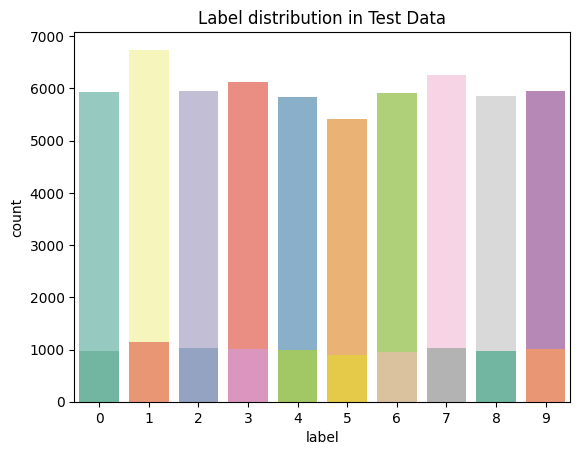

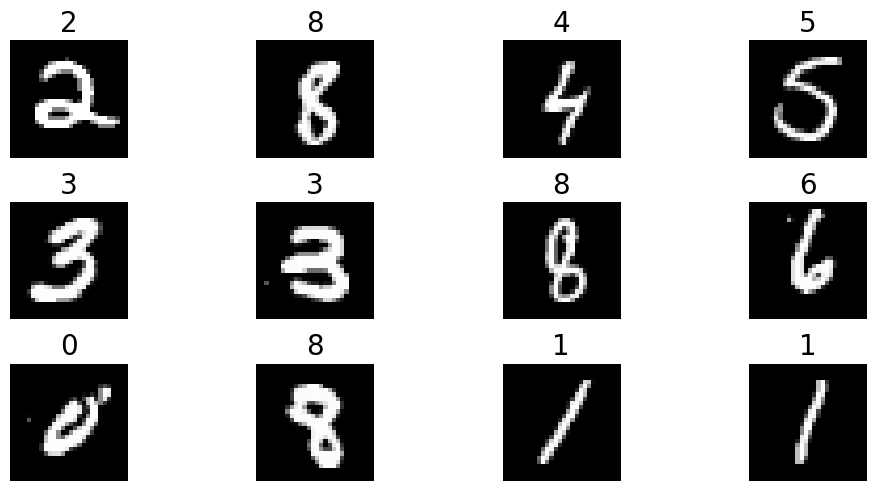

In [2]:
# check if there is any NaN or missing datapoints
mnist_train.isnull().values.sum()

# check label distribution in test and train datasets
sns.countplot(x="label", data=mnist_train, palette="Set3").set(
    title="Label distribution in Training Data")

sns.countplot(x="label", data=mnist_test, palette="Set2").set(
    title="Label distribution in Test Data")

# visualise some of the images from train dataset
# display 4 images per row
fig, axes = plt.subplots(3,4, figsize=(10,5))
# set a tight layout for better spacing between plots
fig.tight_layout()
axes = axes.flatten()
# generate 12 random row numbers to select from mnist_train dataframe
idx = np.random.randint(0,mnist_train.shape[0],size=12)
for i in range(12):
    # get the row data
    pixel_data = mnist_train.iloc[idx[i]]
    # use imshow to build the image using pixel info
    # reshape is necessary because imshow expects a 2d array structure as input
    axes[i].imshow(np.array(pixel_data[:784]).reshape(28,28), cmap='gray')
    axes[i].axis('off')
    # add the label of the image as title
    axes[i].set_title(str(int(pixel_data[-1])), color= 'black', fontsize=20)

import xgboost as xb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# splitting the training data into train and validate datasets
x_train, x_val, y_train, y_val = train_test_split(x_train,
                                                  y_train,
                                                  test_size=0.1)

In [3]:

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, BatchNormalization, LeakyReLU, Reshape, Conv2DTranspose
from tensorflow.keras import optimizers
from tensorflow.keras import models

# add a channel dimension to the images
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
x_val= np.expand_dims(x_val, axis=-1)

# one hot encoding all the labels
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)
y_val = to_categorical(y_val,10)

cnn_model = models.Sequential()

cnn_model.add(Conv2D(filters=20, kernel_size=(5, 5),
                   activation='relu', padding="same",
                   input_shape=(28,28,1)))
cnn_model.add(BatchNormalization(axis=-1))
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv2D(filters=20, kernel_size=(4, 4),
                   activation='relu', padding="same"))
cnn_model.add(BatchNormalization(axis=-1))
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv2D(filters=20, kernel_size=(4, 4),
                   activation='relu', padding="same"))
cnn_model.add(BatchNormalization(axis=-1))
cnn_model.add(Dropout(0.2))

cnn_model.add(Flatten())
cnn_model.add(Dense(200, activation='relu'))

cnn_model.add(Dense(10, activation='softmax'))

cnn_model_opt = optimizers.Adam(decay=1e-4)

print(cnn_model.summary())

cnn_model.compile(optimizer = cnn_model_opt , loss = "categorical_crossentropy",
                  metrics=["accuracy"])

cnn_model_fit = cnn_model.fit(x_train,
                        y_train,
                        validation_data = (x_val, y_val),
                        batch_size=128,
                        epochs=20)

cnn_test_accuracy = cnn_model.evaluate(x_test, y_test)
print("Accuracy on test data is : ", cnn_test_accuracy[1] * 100)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 20)     │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 20)     │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 20)     │         6,420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 20)     │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 20)     │         6,420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 20)     │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15680)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │     3,136,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,151,810 (12.02 MB)

 Trainable params: 3,151,690 (12.02 MB)

 Non-trainable params: 120 (480.00 B)

None
Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.8982 - loss: 0.3994 - val_accuracy: 0.8855 - val_loss: 0.3757
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9842 - loss: 0.0510 - val_accuracy: 0.9808 - val_loss: 0.0671
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9886 - loss: 0.0345 - val_accuracy: 0.9825 - val_loss: 0.0648
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9917 - loss: 0.0270 - val_accuracy: 0.9880 - val_loss: 0.0398
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9943 - loss: 0.0198 - val_accuracy: 0.9870 - val_loss: 0.0466
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9942 - loss: 0.0190 - val_accuracy: 0.9880 - val_loss: 0.0501
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9948 - loss: 0.0158 - val_accuracy: 0.9865 - val_loss: 0.0670
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9942 - loss: 0.0173 - val

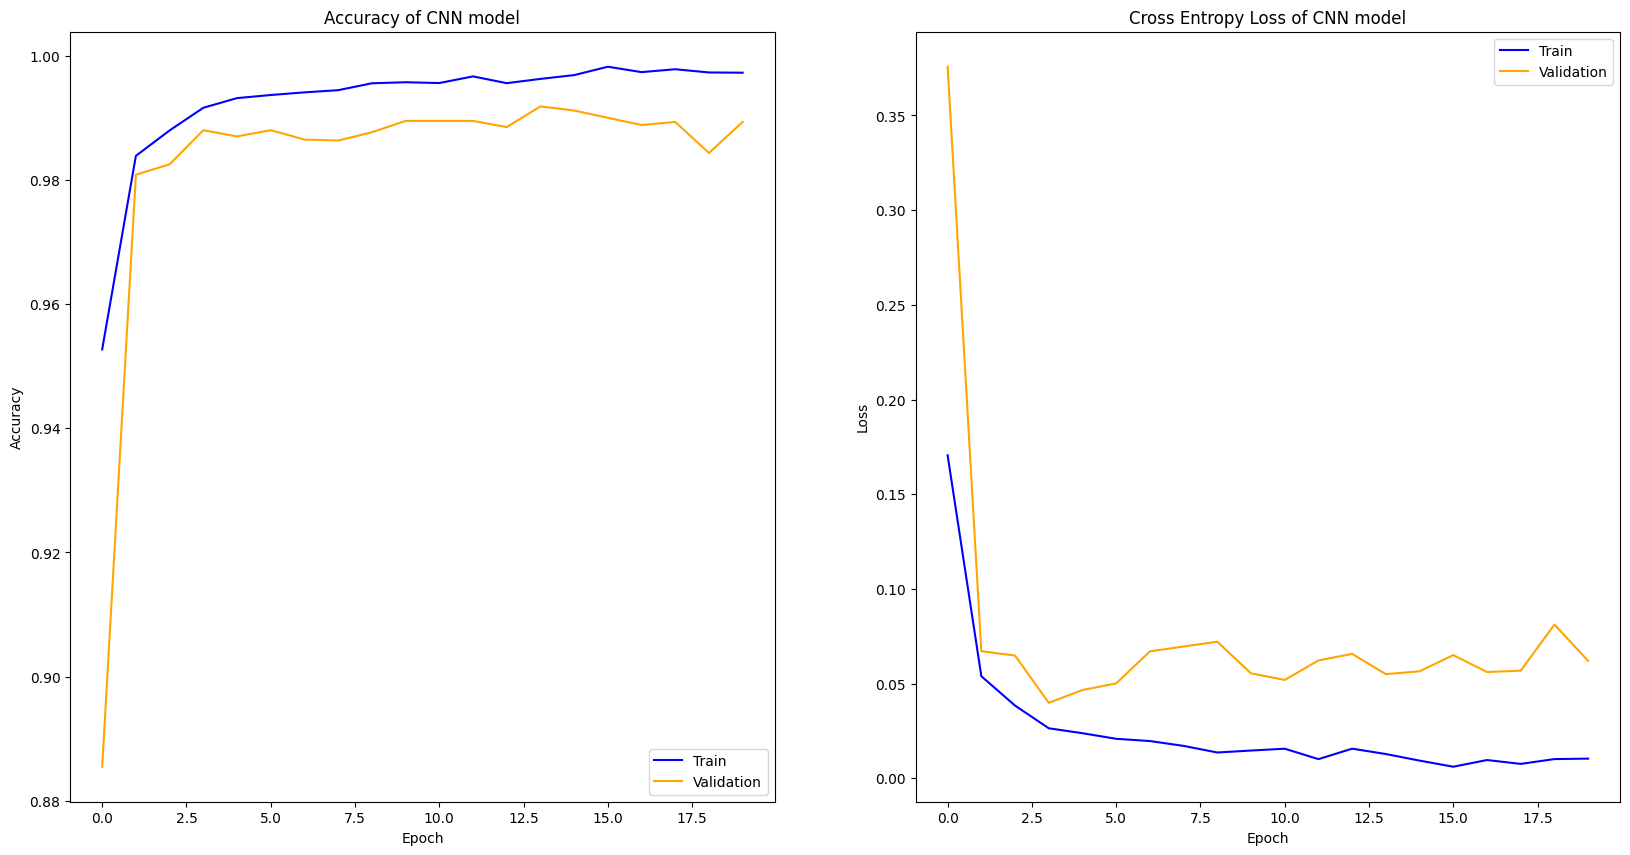

In [4]:
plt.figure(figsize=(20,10))
# plot the accuracy for the train and validation datset
plt.subplot(1,2,1)
plt.plot(cnn_model_fit.history['accuracy'], color='blue',
         label="Training accuracy")
plt.plot(cnn_model_fit.history['val_accuracy'], color='orange',
         label="Validation accuracy")
plt.title("Accuracy of CNN model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"], loc="lower right")

# plot the loss of train and validation dataset
plt.subplot(1,2,2)
plt.plot(cnn_model_fit.history['loss'], color='blue',
         label="Training loss")
plt.plot(cnn_model_fit.history['val_loss'], color='orange',
         label="Validation loss")
plt.title("Cross Entropy Loss of CNN model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"], loc="upper right")



In [6]:

# import numpy as np
# import tensorflow as tf
# from sklearn.metrics import accuracy_score

# # Define the FGSM attack
# def FGSM(model, image, label, eps):
#     image = tf.cast(image, tf.float32)  # Cast image to float32 for gradient calculation
#     with tf.GradientTape() as tape:
#         tape.watch(image)
#         pred = model(image)
#         loss = tf.keras.losses.CategoricalCrossentropy()(label, pred)
#     gradient = tape.gradient(loss, image)
#     signed_grad = tf.sign(gradient)
#     adversary = image + signed_grad * eps
#     return adversary

# # Define the number of test samples to perturb
# eps = 0.1  # Epsilon value for the attack
# num_samples = 100  # Number of test samples to apply the attack

# # Select a subset of the test data
# x_test_subset = x_test[:num_samples]  # Shape: (num_samples, 28, 28, 1)
# y_test_subset = y_test[:num_samples]  # Shape: (num_samples, 10)

# # Ensure images are reshaped correctly
# x_test_subset = np.expand_dims(x_test_subset, axis=-1)  # Shape: (num_samples, 28, 28, 1)
# y_test_subset = np.expand_dims(y_test_subset, axis=-1)  # Shape: (num_samples, 10)

# # Apply FGSM attack to generate adversarial examples
# perturbed_images = []
# for i in range(num_samples):
#     image = x_test_subset[i:i+1]  # Get single image with shape (1, 28, 28, 1)
#     label = y_test_subset[i:i+1]  # Get label with shape (1, 10)
#     perturbed_image = FGSM(cnn_model, image, label, eps)
#     perturbed_images.append(perturbed_image)  # Collect perturbed images

# # Convert list to numpy array
# perturbed_images = np.squeeze(np.array(perturbed_images))  # Shape: (num_samples, 28, 28, 1)

# # Ensure perturbed images have the correct shape for the model (batch_size, 28, 28, 1)
# perturbed_images = np.reshape(perturbed_images, (-1, 28, 28, 1))

# # Make predictions on the perturbed images
# predictions = cnn_model.predict(perturbed_images)  # Predictions for the adversarial images
# predicted_labels = np.argmax(predictions, axis=1)  # Predicted labels
# actual_labels = np.argmax(y_test_subset, axis=1)  # Actual labels

# # Calculate accuracy on the perturbed images
# accuracy = accuracy_score(actual_labels, predicted_labels) * 100
# print(f"Accuracy on perturbed images: {accuracy:.2f}%")
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score

# Define the FGSM attack
def FGSM(model, image, label, eps):
    image = tf.cast(image, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(image)
        pred = model(image)
        loss = tf.keras.losses.CategoricalCrossentropy()(label, pred)
    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    adversary = image + eps * signed_grad
    return tf.clip_by_value(adversary, 0, 1)  # Clip to keep pixels in valid range

# Define list of epsilon values
epsilons = [0.000, 0.007, 0.010, 0.020, 0.030, 0.050, 0.100, 0.200, 0.300]

# Use a subset of test data
num_samples = 100
x_test_subset = x_test[:num_samples]
y_test_subset = y_test[:num_samples]

# Ensure shapes are correct
x_test_subset = np.reshape(x_test_subset, (-1, 28, 28, 1))

# Evaluate accuracy for each epsilon
for eps in epsilons:
    perturbed_images = []

    for i in range(num_samples):
        image = x_test_subset[i:i+1]
        label = y_test_subset[i:i+1]
        perturbed_image = FGSM(cnn_model, image, label, eps)
        perturbed_images.append(perturbed_image)

    perturbed_images = np.squeeze(np.array(perturbed_images))
    perturbed_images = np.reshape(perturbed_images, (-1, 28, 28, 1))

    # Predict on perturbed images
    predictions = cnn_model.predict(perturbed_images)
    predicted_labels = np.argmax(predictions, axis=1)
    actual_labels = np.argmax(y_test_subset, axis=1)

    accuracy = accuracy_score(actual_labels, predicted_labels) * 100
    print(f"Epsilon: {eps:.3f} => Accuracy on perturbed images: {accuracy:.2f}%")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.000 => Accuracy on perturbed images: 99.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.007 => Accuracy on perturbed images: 99.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Epsilon: 0.010 => Accuracy on perturbed images: 99.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.020 => Accuracy on perturbed images: 98.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Epsilon: 0.030 => Accuracy on perturbed images: 97.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Epsilon: 0.050 => Accuracy on perturbed images: 90.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.100 => Accuracy on perturbed images: 78.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.200 => Accuracy on perturbed images: 59.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.300 => Accuracy on perturbed images: 31.00%


In [7]:
# solution to increase the accuracy
# Use Defense Layers
# Add preprocessing layers or transformations like:

# 1) JPEG compression

# 2) Gaussian blur

# 3) Input denoising layers


import cv2
import numpy as np
from sklearn.metrics import accuracy_score

# Gaussian blur preprocessing
def apply_gaussian_blur(images, ksize=3):
    blurred = np.zeros_like(images)
    for i in range(images.shape[0]):
        blurred[i, :, :, 0] = cv2.GaussianBlur(images[i, :, :, 0], (ksize, ksize), 0)
    return blurred

# FGSM attack (reuse)
def FGSM(model, image, label, eps):
    image = tf.cast(image, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(image)
        pred = model(image)
        loss = tf.keras.losses.CategoricalCrossentropy()(label, pred)
    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    adversary = image + eps * signed_grad
    return tf.clip_by_value(adversary, 0, 1)

# Use subset
eps = 0.2
num_samples = 100
x_test_subset = x_test[:num_samples]
y_test_subset = y_test[:num_samples]

# Apply FGSM attack
perturbed_images = []
for i in range(num_samples):
    image = x_test_subset[i:i+1]
    label = y_test_subset[i:i+1]
    perturbed_image = FGSM(cnn_model, image, label, eps)
    perturbed_images.append(perturbed_image)

perturbed_images = np.array(perturbed_images).squeeze()
perturbed_images = perturbed_images.reshape(-1, 28, 28, 1)

# Preprocess (defense layer): Gaussian Blur
blurred_images = apply_gaussian_blur(perturbed_images)

# Evaluate model on blurred adversarial images
predictions = cnn_model.predict(blurred_images)
predicted_labels = np.argmax(predictions, axis=1)
actual_labels = np.argmax(y_test_subset, axis=1)
accuracy = accuracy_score(actual_labels, predicted_labels) * 100
print(f"Accuracy after Gaussian blur on FGSM(ε={eps}): {accuracy:.2f}%")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy after Gaussian blur on FGSM(ε=0.2): 72.00%


In [8]:
import cv2
import numpy as np
from sklearn.metrics import accuracy_score

# Gaussian blur preprocessing
def apply_gaussian_blur(images, ksize=3):
    blurred = np.zeros_like(images)
    for i in range(images.shape[0]):
        blurred[i, :, :, 0] = cv2.GaussianBlur(images[i, :, :, 0], (ksize, ksize), 0)
    return blurred

# FGSM attack function
def FGSM(model, image, label, eps):
    image = tf.cast(image, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(image)
        pred = model(image)
        loss = tf.keras.losses.CategoricalCrossentropy()(label, pred)
    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    adversary = image + eps * signed_grad
    return tf.clip_by_value(adversary, 0, 1)

# Define epsilon values
epsilons = [0.000, 0.007, 0.010, 0.020, 0.030, 0.050, 0.100, 0.200, 0.300]

# Subset of test data
num_samples = 100
x_test_subset = x_test[:num_samples]
y_test_subset = y_test[:num_samples]

# Evaluate over all epsilons
for eps in epsilons:
    perturbed_images = []

    for i in range(num_samples):
        image = x_test_subset[i:i+1]
        label = y_test_subset[i:i+1]
        perturbed_image = FGSM(cnn_model, image, label, eps)
        perturbed_images.append(perturbed_image)

    # Convert and reshape perturbed images
    perturbed_images = np.array(perturbed_images).squeeze().reshape(-1, 28, 28, 1)

    # Apply Gaussian blur defense
    blurred_images = apply_gaussian_blur(perturbed_images)

    # Predict and evaluate
    predictions = cnn_model.predict(blurred_images)
    predicted_labels = np.argmax(predictions, axis=1)
    actual_labels = np.argmax(y_test_subset, axis=1)
    accuracy = accuracy_score(actual_labels, predicted_labels) * 100
    print(f"Epsilon: {eps:.3f} => Accuracy after Gaussian blur: {accuracy:.2f}%")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.000 => Accuracy after Gaussian blur: 98.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.007 => Accuracy after Gaussian blur: 98.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Epsilon: 0.010 => Accuracy after Gaussian blur: 98.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.020 => Accuracy after Gaussian blur: 97.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Epsilon: 0.030 => Accuracy after Gaussian blur: 97.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.050 => Accuracy after Gaussian blur: 93.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.100 => Accuracy after Gaussian blur: 85.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Epsilon: 0.200 => Accuracy after Gaussian blur: 72.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.300 => Accuracy after Gaussian blur: 52.00%


In [9]:
from PIL import Image
import io

# JPEG compression as a defense
def apply_jpeg_compression(images, quality=75):
    compressed = np.zeros_like(images)
    for i in range(images.shape[0]):
        img_array = (images[i, :, :, 0] * 255).astype(np.uint8)  # Convert to 8-bit
        img = Image.fromarray(img_array)
        buffer = io.BytesIO()
        img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        img_compressed = Image.open(buffer)
        compressed[i, :, :, 0] = np.array(img_compressed) / 255.0
    return compressed

# Evaluate using JPEG defense
print("\n--- JPEG Compression Defense ---")
for eps in epsilons:
    perturbed_images = []

    for i in range(num_samples):
        image = x_test_subset[i:i+1]
        label = y_test_subset[i:i+1]
        perturbed_image = FGSM(cnn_model, image, label, eps)
        perturbed_images.append(perturbed_image)

    perturbed_images = np.array(perturbed_images).squeeze().reshape(-1, 28, 28, 1)
    jpeg_images = apply_jpeg_compression(perturbed_images, quality=75)

    predictions = cnn_model.predict(jpeg_images)
    predicted_labels = np.argmax(predictions, axis=1)
    actual_labels = np.argmax(y_test_subset, axis=1)
    accuracy = accuracy_score(actual_labels, predicted_labels) * 100
    print(f"Epsilon: {eps:.3f} => Accuracy after JPEG compression: {accuracy:.2f}%")



--- JPEG Compression Defense ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.000 => Accuracy after JPEG compression: 99.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Epsilon: 0.007 => Accuracy after JPEG compression: 99.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.010 => Accuracy after JPEG compression: 99.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Epsilon: 0.020 => Accuracy after JPEG compression: 99.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.030 => Accuracy after JPEG compression: 98.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.050 => Accuracy after JPEG compression: 94.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.100 => Accuracy after JPEG compression: 79.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.200 => Accuracy after JPEG compression: 63.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.300 => Accuracy after JPEG compression: 31.00%


In [10]:
from scipy.ndimage import median_filter

# Median filter denoising defense
def apply_median_denoising(images, size=3):
    denoised = np.zeros_like(images)
    for i in range(images.shape[0]):
        denoised[i, :, :, 0] = median_filter(images[i, :, :, 0], size=size)
    return denoised

# Evaluate using median denoising
print("\n--- Median Denoising Defense ---")
for eps in epsilons:
    perturbed_images = []

    for i in range(num_samples):
        image = x_test_subset[i:i+1]
        label = y_test_subset[i:i+1]
        perturbed_image = FGSM(cnn_model, image, label, eps)
        perturbed_images.append(perturbed_image)

    perturbed_images = np.array(perturbed_images).squeeze().reshape(-1, 28, 28, 1)
    denoised_images = apply_median_denoising(perturbed_images)

    predictions = cnn_model.predict(denoised_images)
    predicted_labels = np.argmax(predictions, axis=1)
    actual_labels = np.argmax(y_test_subset, axis=1)
    accuracy = accuracy_score(actual_labels, predicted_labels) * 100
    print(f"Epsilon: {eps:.3f} => Accuracy after Median Denoising: {accuracy:.2f}%")



--- Median Denoising Defense ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.000 => Accuracy after Median Denoising: 100.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Epsilon: 0.007 => Accuracy after Median Denoising: 100.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.010 => Accuracy after Median Denoising: 100.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.020 => Accuracy after Median Denoising: 98.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Epsilon: 0.030 => Accuracy after Median Denoising: 97.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.050 => Accuracy after Median Denoising: 92.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.100 => Accuracy after Median Denoising: 81.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Epsilon: 0.200 => Accuracy after Median Denoising: 57.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.300 => Accuracy after Median Denoising: 32.00%


In [12]:
#adversarial training on various various values of epsilon
#it will also help in increasing the accracy


# Prepare training subset
x_train_subset = x_train[:1000]
y_train_subset = y_train[:1000]  # Already one-hot encoded

# Epsilon values
epsilons = [0.01, 0.05, 0.1, 0.2,0.3]

# Generate adversarial samples
adv_images = []
adv_labels = []

for eps in epsilons:
    for i in range(len(x_train_subset)):
        img = x_train_subset[i:i+1]
        lbl = y_train_subset[i:i+1]
        adv = FGSM(cnn_model, img, lbl, eps)
        adv_images.append(adv.numpy().squeeze())
        adv_labels.append(lbl.squeeze())  # still 1D here

# Convert to arrays
adv_images = np.array(adv_images).reshape(-1, 28, 28, 1)

# Fix: make adv_labels a 2D array before one-hot encoding
adv_labels = np.array(adv_labels)
if adv_labels.ndim == 1:
    adv_labels = tf.keras.utils.to_categorical(adv_labels, 10)

# Combine clean + adversarial
x_combined = np.concatenate((x_train_subset, adv_images), axis=0)
y_combined = np.concatenate((y_train_subset, adv_labels), axis=0)

# Retrain model
cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
cnn_model.fit(x_combined, y_combined, batch_size=128, epochs=5, validation_split=0.1)


Epoch 1/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 211ms/step - accuracy: 0.9290 - loss: 0.6115 - val_accuracy: 0.8460 - val_loss: 0.8915
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9937 - loss: 0.0205 - val_accuracy: 0.8880 - val_loss: 0.4159
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9978 - loss: 0.0068 - val_accuracy: 0.9080 - val_loss: 0.3102
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9220 - val_loss: 0.2661
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9988 - loss: 0.0023 - val_accuracy: 0.9400 - val_loss: 0.1825


In [16]:
# Evaluate model on multiple epsilons after adversarial training
print("\n--- Accuracy on FGSM Adversarial Examples (Post-Adversarial Training on different epsilon values ) ---")
epsilons = [0.01, 0.05, 0.1, 0.2,0.3]
# Subset of test data
num_samples = 100
x_test_subset = x_test[:num_samples]
y_test_subset = y_test[:num_samples]

# Loop through each epsilon
for eps in epsilons:
    perturbed_images = []

    for i in range(num_samples):
        image = x_test_subset[i:i+1]
        label = y_test_subset[i:i+1]
        perturbed_image = FGSM(cnn_model, image, label, eps)
        perturbed_images.append(perturbed_image)

    perturbed_images = np.array(perturbed_images).squeeze().reshape(-1, 28, 28, 1)

    predictions = cnn_model.predict(perturbed_images)
    predicted_labels = np.argmax(predictions, axis=1)
    actual_labels = np.argmax(y_test_subset, axis=1)
    accuracy = accuracy_score(actual_labels, predicted_labels) * 100
    print(f"Epsilon: {eps:.3f} => Accuracy after adversarial training: {accuracy:.2f}%")



--- Accuracy on FGSM Adversarial Examples (Post-Adversarial Training on different epsilon values ) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.010 => Accuracy after adversarial training: 99.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Epsilon: 0.050 => Accuracy after adversarial training: 90.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.100 => Accuracy after adversarial training: 84.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.200 => Accuracy after adversarial training: 73.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Epsilon: 0.300 => Accuracy after adversarial training: 56.00%
